In [ ]:
# ==================== BLOCK 1: Install and Import Dependencies ====================
!pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.pipeline import Pipeline

print("All dependencies installed successfully!")

All dependencies installed successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
# ==================== BLOCK 2: Load and Explore Dataset ====================
# Download spam dataset
!wget -nc https://raw.githubusercontent.com/mohitgupta-omg/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv

# Load the dataset
df = pd.read_csv('spam.csv', encoding='latin-1')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# Keep only necessary columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("\nDataset Info:")
print(df.info())

print("\nClass Distribution:")
print(df['label'].value_counts())
print("\nPercentage Distribution:")
print(df['label'].value_counts(normalize=True) * 100)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicate Messages:", df.duplicated().sum())
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

File ‘spam.csv’ already there; not retrieving.

Dataset Shape: (5572, 5)

First 5 rows:
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

C

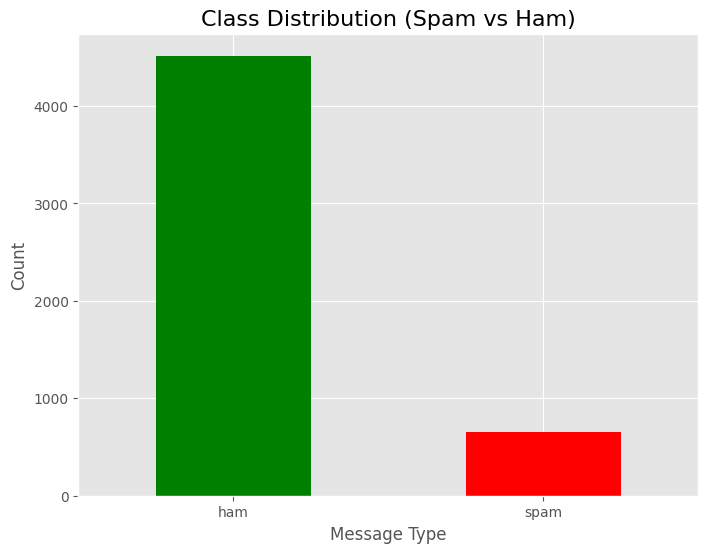

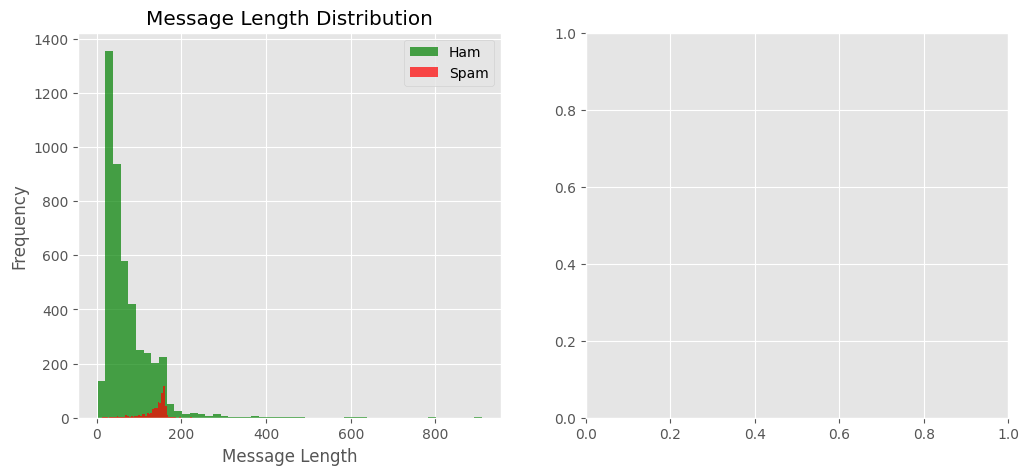

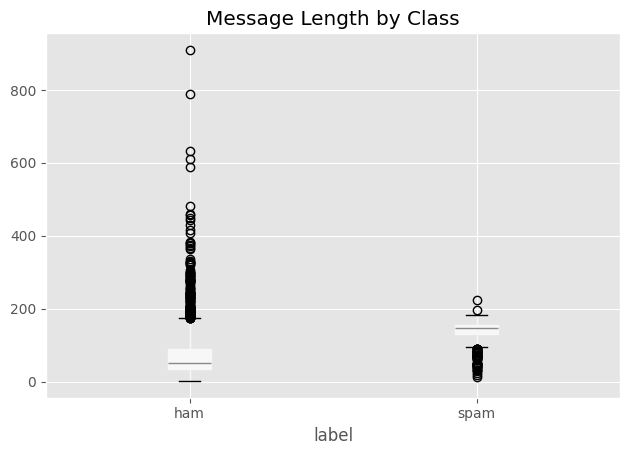

Average Ham Length: 70.46
Average Spam Length: 137.89


In [ ]:
# ==================== BLOCK 3: Exploratory Data Analysis ====================
# Visualize class distribution
plt.figure(figsize=(8, 6))
df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Class Distribution (Spam vs Ham)', fontsize=16)
plt.xlabel('Message Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.show()

# Add message length feature for analysis
df['message_length'] = df['message'].apply(len)

# Compare message lengths between spam and ham
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df[df['label'] == 'ham']['message_length'].hist(bins=50, alpha=0.7, label='Ham', color='green')
df[df['label'] == 'spam']['message_length'].hist(bins=50, alpha=0.7, label='Spam', color='red')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.legend()
plt.title('Message Length Distribution')

plt.subplot(1, 2, 2)
df.boxplot(column='message_length', by='label', patch_artist=True)
plt.title('Message Length by Class')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"Average Ham Length: {df[df['label']=='ham']['message_length'].mean():.2f}")
print(f"Average Spam Length: {df[df['label']=='spam']['message_length'].mean():.2f}")

In [ ]:
# ==================== BLOCK 4: Text Preprocessing Function ====================
nltk.download('punkt_tab')
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Comprehensive text preprocessing function
    """
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and len(token) > 2]

    return ' '.join(tokens)

# Apply preprocessing to messages
print("Applying text preprocessing...")
df['processed_message'] = df['message'].apply(preprocess_text)

# Show before and after
print("\nOriginal Message:")
print(df['message'].iloc[0])
print("\nProcessed Message:")
print(df['processed_message'].iloc[0])

Applying text preprocessing...


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



Original Message:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Processed Message:
jurong point crazy available bugis great world buffet cine got amore wat


In [ ]:
# ==================== BLOCK 5: Prepare Features and Split Data ====================
# Encode labels
df['label_encoded'] = (df['label'] == 'spam').astype(int)

# Split data with stratification to maintain class distribution
X = df['processed_message']
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest set distribution:")
print(y_test.value_counts(normalize=True))

# Create TF-IDF vectorizer with parameters to prevent overfitting
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,           # Limit features to prevent overfitting
    min_df=5,                     # Ignore terms that appear in less than 5 documents
    max_df=0.7,                    # Ignore terms that appear in more than 70% of documents
    ngram_range=(1, 2),            # Use unigrams and bigrams
    sublinear_tf=True              # Use sublinear scaling (1+log(tf))
)

# Transform the data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nTF-IDF matrix shape - Training: {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape - Test: {X_test_tfidf.shape}")

Training set size: 4135
Test set size: 1034

Training set distribution:
label_encoded
0    0.873761
1    0.126239
Name: proportion, dtype: float64

Test set distribution:
label_encoded
0    0.873308
1    0.126692
Name: proportion, dtype: float64

TF-IDF matrix shape - Training: (4135, 1435)
TF-IDF matrix shape - Test: (1034, 1435)


In [ ]:
# ==================== BLOCK 6: Model Training with Cross-Validation ====================
# Define models with regularization to prevent overfitting
models = {
    'Naive Bayes': MultinomialNB(alpha=0.5),  # Add smoothing
    'Logistic Regression': LogisticRegression(C=0.1, max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    )
}

# Perform cross-validation and training
results = {}
cv_scores = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")

    # Perform 5-fold cross-validation
    cv_scores[name] = cross_val_score(model, X_train_tfidf, y_train, cv=5, scoring='f1')

    print(f"Cross-validation F1 scores: {cv_scores[name]}")
    print(f"Mean CV F1 score: {cv_scores[name].mean():.4f} (+/- {cv_scores[name].std() * 2:.4f})")

    # Train on full training set
    model.fit(X_train_tfidf, y_train)

    # Predictions
    y_pred_train = model.predict(X_train_tfidf)
    y_pred_test = model.predict(X_test_tfidf)

    # Calculate metrics
    results[name] = {
        'train_accuracy': accuracy_score(y_train, y_pred_train),
        'test_accuracy': accuracy_score(y_test, y_pred_test),
        'precision': precision_score(y_test, y_pred_test),
        'recall': recall_score(y_test, y_pred_test),
        'f1': f1_score(y_test, y_pred_test),
        'model': model
    }

    print(f"\nTest Set Performance:")
    print(f"Accuracy: {results[name]['test_accuracy']:.4f}")
    print(f"Precision: {results[name]['precision']:.4f}")
    print(f"Recall: {results[name]['recall']:.4f}")
    print(f"F1-Score: {results[name]['f1']:.4f}")


Training Naive Bayes...
Cross-validation F1 scores: [0.875      0.89119171 0.88541667 0.89340102 0.92385787]
Mean CV F1 score: 0.8938 (+/- 0.0327)

Test Set Performance:
Accuracy: 0.9749
Precision: 0.9565
Recall: 0.8397
F1-Score: 0.8943

Training Logistic Regression...
Cross-validation F1 scores: [0. 0. 0. 0. 0.]
Mean CV F1 score: 0.0000 (+/- 0.0000)

Test Set Performance:
Accuracy: 0.8733
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

Training Random Forest...
Cross-validation F1 scores: [0.43609023 0.49275362 0.49275362 0.58108108 0.58108108]
Mean CV F1 score: 0.5168 (+/- 0.1129)

Test Set Performance:
Accuracy: 0.9217
Precision: 1.0000
Recall: 0.3817
F1-Score: 0.5525

Training Gradient Boosting...
Cross-validation F1 scores: [0.79120879 0.80681818 0.79558011 0.82539683 0.84042553]
Mean CV F1 score: 0.8119 (+/- 0.0371)

Test Set Performance:
Accuracy: 0.9652
Precision: 0.9703
Recall: 0.7481
F1-Score: 0.8448


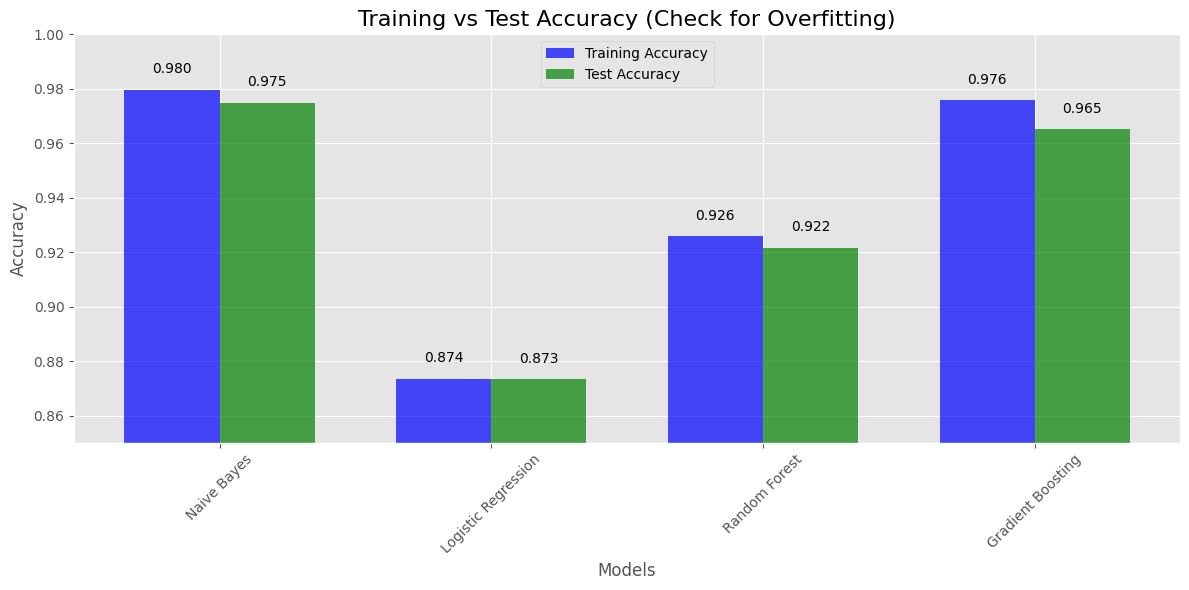


Overfitting Analysis:
--------------------------------------------------
Naive Bayes: Train-Test Gap = 0.0048 - Good
Logistic Regression: Train-Test Gap = 0.0002 - Good
Random Forest: Train-Test Gap = 0.0041 - Good
Gradient Boosting: Train-Test Gap = 0.0106 - Good


In [ ]:
# ==================== BLOCK 7: Check for Overfitting ====================
# Compare train vs test performance to detect overfitting
plt.figure(figsize=(12, 6))

models_list = list(results.keys())
train_scores = [results[m]['train_accuracy'] for m in models_list]
test_scores = [results[m]['test_accuracy'] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

plt.bar(x - width/2, train_scores, width, label='Training Accuracy', color='blue', alpha=0.7)
plt.bar(x + width/2, test_scores, width, label='Test Accuracy', color='green', alpha=0.7)

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy (Check for Overfitting)', fontsize=16)
plt.xticks(x, models_list, rotation=45)
plt.legend()
plt.ylim(0.85, 1.0)

# Add value labels
for i, (train, test) in enumerate(zip(train_scores, test_scores)):
    plt.text(i - width/2, train + 0.005, f'{train:.3f}', ha='center', va='bottom')
    plt.text(i + width/2, test + 0.005, f'{test:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Calculate overfitting score (difference between train and test)
print("\nOverfitting Analysis:")
print("-" * 50)
for model in models_list:
    diff = results[model]['train_accuracy'] - results[model]['test_accuracy']
    status = "Good" if diff < 0.02 else "Mild Overfitting" if diff < 0.05 else "Significant Overfitting"
    print(f"{model}: Train-Test Gap = {diff:.4f} - {status}")

Best Model: Naive Bayes
Test F1 Score: 0.8943
Train-Test Gap: 0.0048


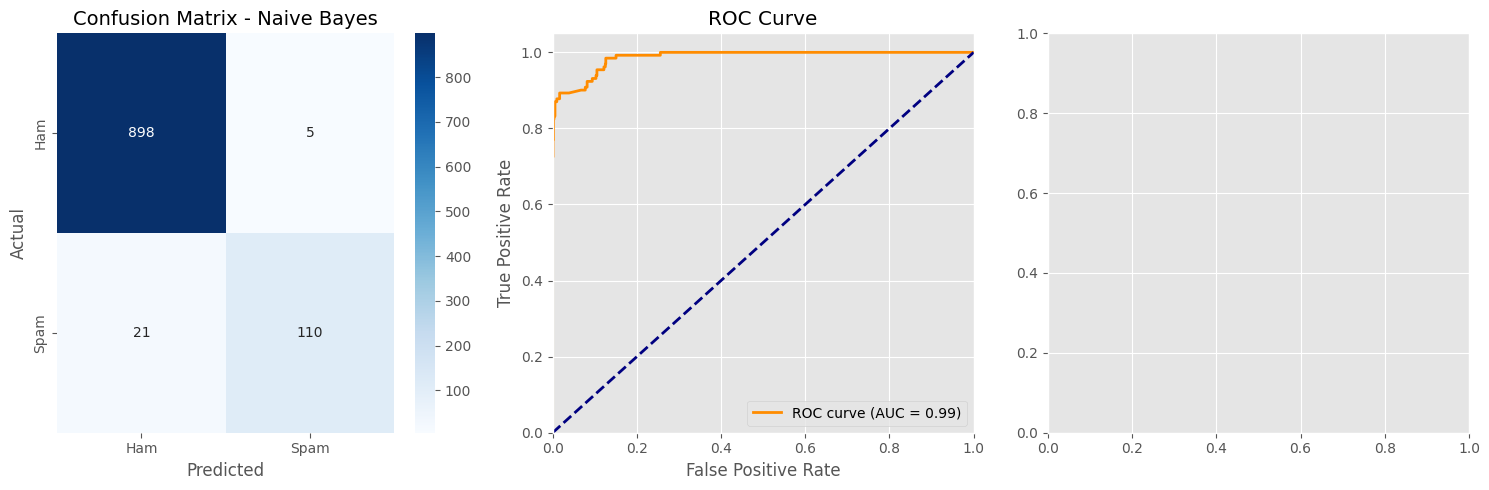

In [ ]:
# ==================== BLOCK 8: Model Evaluation and Visualization ====================
# Select best model based on F1 score and generalization
best_model_name = max(results.keys(), key=lambda x: results[x]['f1'] - (results[x]['train_accuracy'] - results[x]['test_accuracy']))
best_model = results[best_model_name]['model']

print(f"Best Model: {best_model_name}")
print(f"Test F1 Score: {results[best_model_name]['f1']:.4f}")
print(f"Train-Test Gap: {results[best_model_name]['train_accuracy'] - results[best_model_name]['test_accuracy']:.4f}")

# Get predictions from best model
y_pred_best = best_model.predict(X_test_tfidf)
y_pred_proba = best_model.predict_proba(X_test_tfidf)[:, 1]

# Confusion Matrix
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')

# ROC Curve
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

# Feature Importance (for tree-based models)
plt.subplot(1, 3, 3)
if hasattr(best_model, 'feature_importances_'):
    feature_names = tfidf_vectorizer.get_feature_names_out()
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[-15:]

    plt.barh(range(15), importances[indices])
    plt.yticks(range(15), [feature_names[i] for i in indices])
    plt.xlabel('Feature Importance')
    plt.title('Top 15 Important Features')
elif hasattr(best_model, 'coef_'):
    feature_names = tfidf_vectorizer.get_feature_names_out()
    coef = best_model.coef_[0]
    indices = np.argsort(coef)[-15:]

    plt.barh(range(15), coef[indices])
    plt.yticks(range(15), [feature_names[i] for i in indices])
    plt.xlabel('Coefficient Value')
    plt.title('Top 15 Features by Coefficient')

plt.tight_layout()
plt.show()

In [ ]:
# ==================== BLOCK 9: Hyperparameter Tuning for Best Model ====================
# Further optimize the best model to ensure no overfitting
print(f"Performing hyperparameter tuning for {best_model_name}...")

if best_model_name == 'Naive Bayes':
    param_grid = {'alpha': [0.1, 0.5, 1.0, 2.0]}
elif best_model_name == 'Logistic Regression':
    param_grid = {'C': [0.01, 0.1, 1.0, 10.0], 'penalty': ['l2']}
elif best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [5, 10, 15],
        'min_samples_split': [5, 10]
    }
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1]
    }

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    best_model,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_tfidf, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

# Evaluate tuned model on test set
y_pred_tuned = grid_search.predict(X_test_tfidf)
print(f"\nTuned Model Test Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_tuned):.4f}")

# Check if tuning helped
if f1_score(y_test, y_pred_tuned) > results[best_model_name]['f1']:
    print("\n✓ Hyperparameter tuning improved the model!")
    best_model = grid_search.best_estimator_
else:
    print("\nℹ Hyperparameter tuning didn't improve - keeping original model")

Performing hyperparameter tuning for Naive Bayes...

Best parameters: {'alpha': 0.1}
Best cross-validation F1 score: 0.8996

Tuned Model Test Performance:
Accuracy: 0.9768
F1 Score: 0.9032

✓ Hyperparameter tuning improved the model!


In [ ]:
# ==================== BLOCK 10: Test on New Examples ====================
def predict_spam(message, model, vectorizer):
    """
    Function to predict if a new message is spam or ham
    """
    processed = preprocess_text(message)
    features = vectorizer.transform([processed])
    prediction = model.predict(features)[0]
    probability = model.predict_proba(features)[0]

    return {
        'message': message,
        'is_spam': bool(prediction),
        'confidence': float(probability[1] if prediction else probability[0]),
        'processed_message': processed
    }

# Test examples
test_messages = [
    "Congratulations! You've won a free iPhone! Click here to claim your prize now!",
    "Hey, are we still meeting for lunch tomorrow at 12?",
    "URGENT: Your account has been suspended. Verify immediately: http://fake-link.com",
    "Can you pick up some milk on your way home?",
    "FREE MONEY!!! Make $5000 per week working from home!!! Limited time offer!!!",
    "The project deadline has been extended to Friday. Please review the attached document.",
    "You have been selected for a $1000 Walmart gift card. Call now!",
    "Don't forget to bring your laptop to the meeting tomorrow."
]

print("Testing Model on New Messages:")
print("=" * 70)

for i, msg in enumerate(test_messages, 1):
    result = predict_spam(msg, best_model, tfidf_vectorizer)

    status = "🔴 SPAM" if result['is_spam'] else "🟢 HAM"
    confidence = result['confidence'] * 100

    print(f"\n{i}. Message: {msg[:60]}..." if len(msg) > 60 else f"\n{i}. Message: {msg}")
    print(f"   Status: {status} (Confidence: {confidence:.2f}%)")

Testing Model on New Messages:

1. Message: Congratulations! You've won a free iPhone! Click here to cla...
   Status: 🔴 SPAM (Confidence: 99.97%)

2. Message: Hey, are we still meeting for lunch tomorrow at 12?
   Status: 🟢 HAM (Confidence: 99.95%)

3. Message: URGENT: Your account has been suspended. Verify immediately:...
   Status: 🔴 SPAM (Confidence: 94.82%)

4. Message: Can you pick up some milk on your way home?
   Status: 🟢 HAM (Confidence: 99.88%)

5. Message: FREE MONEY!!! Make $5000 per week working from home!!! Limit...
   Status: 🟢 HAM (Confidence: 73.44%)

6. Message: The project deadline has been extended to Friday. Please rev...
   Status: 🟢 HAM (Confidence: 96.95%)

7. Message: You have been selected for a $1000 Walmart gift card. Call n...
   Status: 🔴 SPAM (Confidence: 57.79%)

8. Message: Don't forget to bring your laptop to the meeting tomorrow.
   Status: 🟢 HAM (Confidence: 99.81%)


In [ ]:
# ==================== BLOCK 11: Final Model Performance Summary ====================
# Create comprehensive performance summary
print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*70)

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Ham', 'Spam']))

# Metrics summary
metrics_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Accuracy': [results[m]['train_accuracy'] for m in results.keys()],
    'Test Accuracy': [results[m]['test_accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1'] for m in results.keys()],
    'Overfitting Gap': [results[m]['train_accuracy'] - results[m]['test_accuracy'] for m in results.keys()]
})

print("\nAll Models Comparison:")
print(metrics_df.to_string(index=False))

# Highlight best model
print("\n" + "="*70)
print(f"✅ BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {results[best_model_name]['test_accuracy']:.4f}")
print(f"   Test F1-Score: {results[best_model_name]['f1']:.4f}")
print(f"   Precision: {results[best_model_name]['precision']:.4f}")
print(f"   Recall: {results[best_model_name]['recall']:.4f}")
print(f"   Overfitting Gap: {results[best_model_name]['train_accuracy'] - results[best_model_name]['test_accuracy']:.4f}")
print("="*70)

# Save the model (optional)
import joblib
joblib.dump(best_model, 'best_spam_model.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
print("\n✓ Model and vectorizer saved successfully!")


FINAL MODEL PERFORMANCE SUMMARY

Detailed Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.96      0.84      0.89       131

    accuracy                           0.97      1034
   macro avg       0.97      0.92      0.94      1034
weighted avg       0.97      0.97      0.97      1034


All Models Comparison:
              Model  Train Accuracy  Test Accuracy  Precision   Recall  F1-Score  Overfitting Gap
        Naive Bayes        0.979686       0.974855   0.956522 0.839695  0.894309         0.004831
Logistic Regression        0.873519       0.873308   0.000000 0.000000  0.000000         0.000211
      Random Forest        0.925756       0.921663   1.000000 0.381679  0.552486         0.004092
  Gradient Boosting        0.975816       0.965184   0.970297 0.748092  0.844828         0.010632

✅ BEST MODEL: Naive Bayes
   Test Accuracy: 0.9749
   Test F1-Score: 0.8943
   Precision: 0.